# Wells and production technology: from well construction to intervention

This notebook connects **drilling, completion, production, artificial lift, injection, and intervention** as one decision loop. Python handles survey geometry, data tables, optimization, uncertainty, and visualization; NeqSim Java `master` supplies the well, cost, lift, injection, integrity, and treatment physics.

The case is illustrative screening, not a certified well design. Replace the synthetic trajectory, rock/fluid data, operating limits, costs, and barrier evidence with governed field inputs before decisions.

## Where this sits in the value chain

| Decision | Primary evidence | NeqSim role | Python role |
|---|---|---|---|
| Drill the well | trajectory, casing basis, time | `SubseaWell`, `WellCostEstimator` | minimum-curvature survey and plots |
| Complete it | PI, skin, barriers | completion type and well configuration | completion sensitivity |
| Produce it | reservoir and wellhead envelope | `ArtificialLiftScreener` | ranking and economics display |
| Inject | injectivity and pressure limits | `InjectionWellModel` | operating envelope visualization |
| Intervene | annulus/barrier/scale evidence | `WellIntegrityScreening`, `AcidTreatmentSimulator` | evidence table and decision logic |


In [1]:
import importlib.util
from importlib.metadata import PackageNotFoundError, version
import os
from pathlib import Path
import subprocess
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/neqsim-value-chain-matplotlib")
SUPPORT_PACKAGES = {
    "jpype": "jpype1",
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pandas": "pandas",
    "scipy": "scipy",
}
missing = [package for module, package in SUPPORT_PACKAGES.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", "--no-cache-dir", *missing],
        check=True,
        timeout=900,
    )
print("Python dependency gate passed.")


Python dependency gate passed.


In [2]:
import hashlib
import json
import math
import os
import platform
from pathlib import Path
import subprocess

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import optimize, stats

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 115, "axes.titlesize": 11, "axes.labelsize": 10})
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.4g}")

package_versions = pd.DataFrame({
    "package": ["Python", "JPype", "NumPy", "Pandas", "SciPy", "Matplotlib"],
    "version": [platform.python_version(), version("jpype1"), version("numpy"),
                version("pandas"), version("scipy"), version("matplotlib")],
})
display(package_versions)


,package,version
0,Python,3.12.13
1,JPype,1.7.1
2,NumPy,2.5.1
3,Pandas,3.0.5
4,SciPy,1.18.0
5,Matplotlib,3.11.1


## Reproducible NeqSim Java `master`

The next cell clones/builds `equinor/neqsim` from `master` in Colab, records the exact commit and JAR SHA-256, disables Python-wrapper JVM autostart, and proves that a capability available on current `master` is loaded from that JAR. A local validator may inject an already compiled source tree and dependency classpath through environment variables.


In [3]:
def run_command(command, *, cwd=None, timeout=1200):
    result = subprocess.run(
        command, cwd=cwd, text=True, stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT, timeout=timeout,
    )
    if result.returncode != 0:
        tail = "\n".join(result.stdout.splitlines()[-80:])
        raise RuntimeError(f"Command failed ({result.returncode}): {command}\n{tail}")
    return result.stdout.strip()

NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
supplied_source = os.environ.get("NEQSIM_SOURCE_ROOT", "").strip()
supplied_jar = os.environ.get("NEQSIM_SOURCE_JAR", "").strip()

if supplied_source and supplied_jar:
    neqsim_source = Path(supplied_source).resolve()
    neqsim_jar = Path(supplied_jar).resolve()
else:
    build_root = Path("/content") if Path("/content").exists() else Path.cwd()
    neqsim_source = build_root / "neqsim-java-master"
    if not neqsim_source.exists():
        run_command([
            "git", "clone", "--depth", "1", "--branch", NEQSIM_SOURCE_REF,
            "https://github.com/equinor/neqsim.git", str(neqsim_source),
        ], timeout=600)
    else:
        run_command(["git", "fetch", "--depth", "1", "origin", NEQSIM_SOURCE_REF],
                    cwd=neqsim_source, timeout=600)
        run_command(["git", "checkout", "--detach", "FETCH_HEAD"], cwd=neqsim_source)
    run_command([
        "./mvnw", "-q", "-DskipTests", "-Dmaven.javadoc.skip=true", "package",
    ], cwd=neqsim_source, timeout=1500)
    built_jars = sorted(
        path for path in (neqsim_source / "target").glob("neqsim-*.jar")
        if "sources" not in path.name and "javadoc" not in path.name
        and not path.name.startswith("original-")
    )
    if not built_jars:
        raise FileNotFoundError("Maven completed but no NeqSim JAR was found.")
    neqsim_jar = built_jars[-1]

if not neqsim_source.is_dir() or not neqsim_jar.is_file():
    raise FileNotFoundError("NeqSim source root or built JAR is missing.")

neqsim_commit = run_command(["git", "rev-parse", "HEAD"], cwd=neqsim_source)
neqsim_jar_sha256 = hashlib.sha256(neqsim_jar.read_bytes()).hexdigest()

os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
if not jpype.isJVMStarted():
    jpype.addClassPath(str(neqsim_jar))
    local_m2 = os.environ.get("NEQSIM_VALIDATION_M2", "").strip()
    if local_m2:
        for dependency in sorted(Path(local_m2).rglob("*.jar")):
            if dependency.resolve() != neqsim_jar:
                jpype.addClassPath(str(dependency))
    jpype.startJVM()

JClass = jpype.JClass
MainOnlyClass = JClass("neqsim.process.equipment.subsea.SubseaWell")
class_source = str(
    MainOnlyClass.class_.getProtectionDomain().getCodeSource().getLocation()
)
if neqsim_jar.name not in class_source:
    raise RuntimeError("NeqSim classes were not loaded from the source-built JAR.")

provenance_table = pd.DataFrame({
    "item": ["NeqSim source ref", "NeqSim commit", "JAR SHA-256", "Java class source"],
    "resolved value": [NEQSIM_SOURCE_REF, neqsim_commit, neqsim_jar_sha256, class_source],
})
display(provenance_table)


,item,resolved value
0,NeqSim source ref,master
1,NeqSim commit,df68ad7295b9dae6a324d941761a303d9f301fb5
2,JAR SHA-256,45180d03ae275a12bc50342a098c50dae93fe544b69686...
3,Java class source,file:/workspace/scratch/2a202e14c527/neqsim-ja...


## 1. Drilling: a survey is the spatial backbone

Minimum curvature converts measured-depth stations to north/east/TVD increments. For dogleg angle $\beta$ and course length $\Delta MD$, the ratio factor is

$$RF = \frac{2}{\beta}\tan\left(\frac{\beta}{2}\right)$$

with $RF=1$ as $\beta\to0$. The trajectory links the reservoir target to casing, completion, hydraulics, intervention access, and cost.


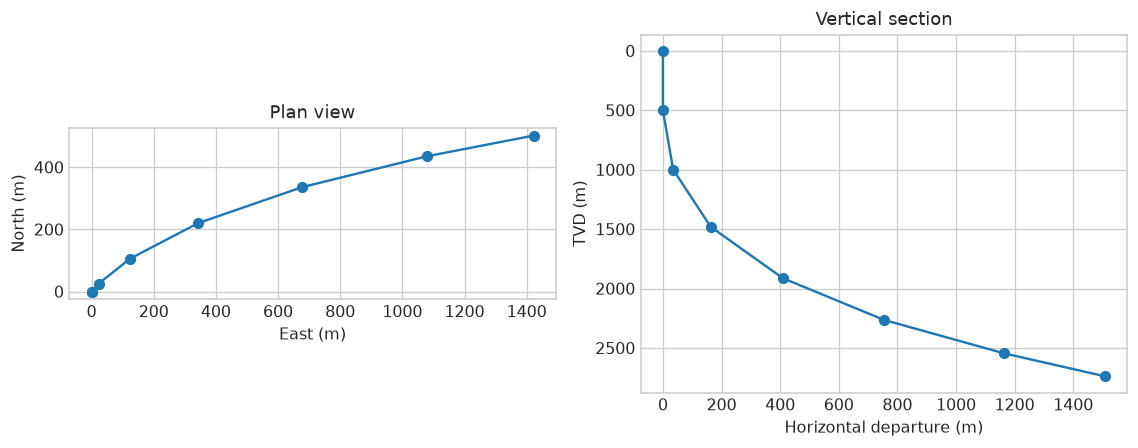

,MD_m,inc_deg,azi_deg,North_m,East_m,TVD_m,DLS_deg_per_30m
0,0,0,35,0,0,0,0
1,500,0,35,0,0,500,0
2,1000,8,42,25.9,23.32,998.4,0.48
3,1500,22,55,105.9,123.8,"1,480",0.86
4,2000,38,67,220.6,343.9,"1,912",1.02
5,2500,52,74,335.7,676.8,"2,265",0.89
6,3000,60,78,435.2,"1,079","2,545",0.52
7,3400,62,80,501.9,"1,422","2,738",0.2


In [4]:
survey = pd.DataFrame({
    "MD_m": [0, 500, 1000, 1500, 2000, 2500, 3000, 3400],
    "inc_deg": [0, 0, 8, 22, 38, 52, 60, 62],
    "azi_deg": [35, 35, 42, 55, 67, 74, 78, 80],
})

def minimum_curvature(frame):
    north = [0.0]; east = [0.0]; tvd = [0.0]; dls = [0.0]
    for i in range(1, len(frame)):
        md = frame.MD_m.iloc[i] - frame.MD_m.iloc[i-1]
        i1, i2 = np.deg2rad(frame.inc_deg.iloc[[i-1, i]])
        a1, a2 = np.deg2rad(frame.azi_deg.iloc[[i-1, i]])
        cos_beta = np.clip(np.cos(i2-i1) - np.sin(i1)*np.sin(i2)*(1-np.cos(a2-a1)), -1, 1)
        beta = np.arccos(cos_beta)
        rf = 1.0 if abs(beta) < 1e-10 else 2.0/beta*np.tan(beta/2.0)
        north.append(north[-1] + md/2*(np.sin(i1)*np.cos(a1)+np.sin(i2)*np.cos(a2))*rf)
        east.append(east[-1] + md/2*(np.sin(i1)*np.sin(a1)+np.sin(i2)*np.sin(a2))*rf)
        tvd.append(tvd[-1] + md/2*(np.cos(i1)+np.cos(i2))*rf)
        dls.append(np.rad2deg(beta)*30/md)
    return frame.assign(North_m=north, East_m=east, TVD_m=tvd, DLS_deg_per_30m=dls)

survey = minimum_curvature(survey)
assert survey.TVD_m.is_monotonic_increasing and survey.DLS_deg_per_30m.max() < 3.0

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(survey.East_m, survey.North_m, "o-")
axes[0].set(title="Plan view", xlabel="East (m)", ylabel="North (m)", aspect="equal")
axes[1].plot(np.hypot(survey.East_m, survey.North_m), survey.TVD_m, "o-")
axes[1].invert_yaxis(); axes[1].set(title="Vertical section", xlabel="Horizontal departure (m)", ylabel="TVD (m)")
plt.tight_layout(); plt.show()
display(survey.round(2))


## 2. Well construction and completion basis

NeqSim carries the same geometry into a `SubseaWell` object and screens drilling/completion cost. The cost model is a transparent concept-level estimate, not an AFE. Completion skin is then varied in Python to show why completion quality changes the production envelope inherited by artificial-lift and facility studies.


In [5]:
SystemSrkEos = JClass("neqsim.thermo.system.SystemSrkEos")
Stream = JClass("neqsim.process.equipment.stream.Stream")
SubseaWell = JClass("neqsim.process.equipment.subsea.SubseaWell")
WellCostEstimator = JClass("neqsim.process.mechanicaldesign.subsea.WellCostEstimator")
Region = JClass("neqsim.process.mechanicaldesign.subsea.SubseaCostEstimator$Region")

fluid = SystemSrkEos(273.15 + 82.0, 245.0)
for component, amount in {"methane": 62, "ethane": 6, "propane": 4, "n-heptane": 20, "water": 8}.items():
    fluid.addComponent(component, amount)
fluid.setMixingRule("classic"); fluid.setMultiPhaseCheck(True)
reservoir_stream = Stream("Reservoir fluid", fluid)
reservoir_stream.setFlowRate(8500.0, "kg/hr")

well = SubseaWell("A-12 producer", reservoir_stream)
well.setWellType(SubseaWell.WellType.OIL_PRODUCER)
well.setCompletionType(SubseaWell.CompletionType.CASED_PERFORATED)
well.setRigType(SubseaWell.RigType.SEMI_SUBMERSIBLE)
well.setMeasuredDepth(float(survey.MD_m.iloc[-1])); well.setTrueVerticalDepth(float(survey.TVD_m.iloc[-1]))
well.setWaterDepth(360.0); well.setMaxInclination(float(survey.inc_deg.max()))
well.setDrillingDays(62.0); well.setCompletionDays(28.0); well.setHasDHSV(True)

cost = WellCostEstimator(Region.NORWAY)
cost.calculateWellCost("OIL_PRODUCER", "SEMI_SUBMERSIBLE", "CASED_PERFORATED",
                       well.getMeasuredDepth(), well.getWaterDepth(), 62.0, 28.0, 0.0, True, 5)
cost_table = pd.DataFrame({"element": ["Drilling", "Completion", "Casing", "Cement", "Contingency", "Total"],
                           "MUSD": np.array([cost.getDrillingCost(), cost.getCompletionCost(),
                                             cost.getCasingMaterialCost(), cost.getCementCost(),
                                             cost.getContingencyCost(), cost.getTotalCost()])/1e6})
assert cost.getTotalCost() > cost.getDrillingCost() > 0
display(cost_table.round(2))

skin_cases = pd.DataFrame({"completion": ["damaged", "base cased/perforated", "stimulated"], "skin": [8, 3, -1]})
kh_factor = np.log(500/0.10)
skin_cases["PI_Sm3d_bar"] = 10.0*(kh_factor + 3)/(kh_factor + skin_cases.skin)
skin_cases["rate_at_60bar_drawdown_Sm3d"] = skin_cases.PI_Sm3d_bar*60
display(skin_cases.round(1))


,element,MUSD
0,Drilling,33.48
1,Completion,22.54
2,Casing,2.48
3,Cement,1.15
4,Contingency,10.11
5,Total,77.52


,completion,skin,PI_Sm3d_bar,rate_at_60bar_drawdown_Sm3d
0,damaged,8,7,418.4
1,base cased/perforated,3,10,600
2,stimulated,-1,15.3,919.3


## 3. Artificial lift: screen the operating envelope

Natural flow, gas lift, ESP, rod pump, PCP, and jet-pump concepts are evaluated with the same reservoir pressure, depth, PI, water cut, GOR, fluid viscosity, utilities, and commercial basis. A Python engineering-validity overlay rejects any reported-feasible result with negative rate or power. Ranking is a screening result: detailed nodal analysis, transient behavior, solids tolerance, operability, and vendor curves still govern selection.


,method,reported_feasible,rate_Sm3d,power_kW,NPV_MUSD,rank,engineering_valid
0,Gas Lift,True,"2,067",1.818e+04,"1,985",1,True
1,Jet Pump,True,875,306.2,923.5,2,True
2,Natural Flow,True,633.5,0,670.3,3,True
3,ESP,False,0,0,0,0,False
4,PCP,False,0,0,0,0,False
5,Rod Pump,True,-468.5,-70.27,NaN,4,False


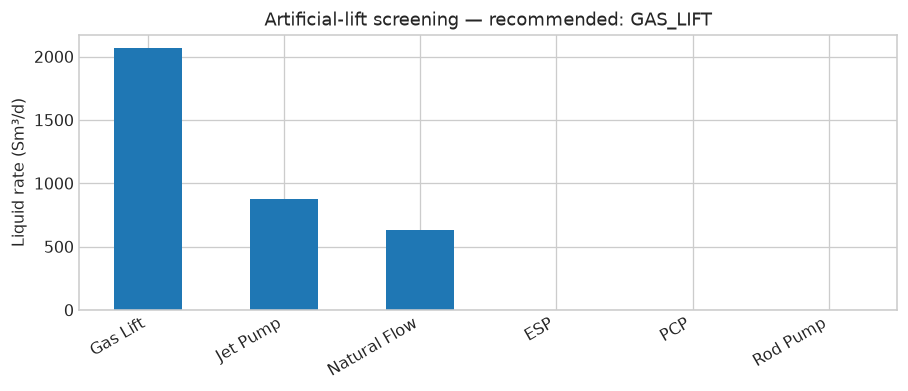

In [6]:
ArtificialLiftScreener = JClass("neqsim.process.fielddevelopment.screening.ArtificialLiftScreener")
screener = ArtificialLiftScreener()
screener.setReservoirPressure(245.0, "bara").setReservoirTemperature(82.0, "C")
screener.setWellheadPressure(18.0, "bara").setWellDepth(float(survey.TVD_m.iloc[-1]), "m")
screener.setProductivityIndex(float(skin_cases.loc[1, "PI_Sm3d_bar"]))
screener.setOilGravity(33.0, "API").setWaterCut(0.48).setFormationGOR(135.0)
screener.setOilViscosity(4.0, "cP").setGasLiftAvailable(True).setElectricityAvailable(True)
screener.setGasLiftPressure(145.0).setElectricityPower(1800.0).setOilPrice(75.0)
lift_result = screener.screen()
lift_rows = [{"method": str(x.getMethodName()), "feasible": bool(x.feasible),
              "rate_Sm3d": float(x.productionRate), "power_kW": float(x.powerConsumption),
              "NPV_MUSD": float(x.npv)/1e6 if np.isfinite(float(x.npv)) else np.nan,
              "rank": int(x.rank)} for x in lift_result.getAllMethods()]
lift_table = pd.DataFrame(lift_rows).rename(columns={"feasible": "reported_feasible"})
lift_table["engineering_valid"] = lift_table.reported_feasible & (lift_table.rate_Sm3d >= 0) & (lift_table.power_kW >= 0)
lift_table = lift_table.sort_values(["engineering_valid", "rank"], ascending=[False, True])
assert lift_table.engineering_valid.any() and lift_table.rate_Sm3d.max() > 0
display(lift_table.round(2))

plot_rates = lift_table.set_index("method").rate_Sm3d.where(lift_table.set_index("method").engineering_valid, 0)
ax = plot_rates.plot.bar(figsize=(8, 3.5), color="#1f77b4")
ax.set(title=f"Artificial-lift screening — recommended: {lift_result.getRecommendedMethod()}", ylabel="Liquid rate (Sm³/d)", xlabel="")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()


## 4. Injection: protect the fracture-pressure ceiling

For a target injection rate $q$, NeqSim estimates injectivity $II$ and the required bottom-hole pressure

$$p_{bh}=p_r+\frac{q}{II}$$

then limits the achievable rate at the configured maximum BHP/fracture envelope and estimates surface pressure and pump power. Real projects require falloff tests, water-quality/compatibility evidence, thermal-fracture review, and surveillance.


,target_Sm3d,achievable_Sm3d,BHP_bara,WHP_bara,pump_kW,pressure_limited
0,"1,000","1,000",251.9,10,0,False
1,"2,000","2,000",265.7,10,0,False
2,"3,000","3,000",279.6,10,0,False
3,"4,000","3,893",292,11.78,0,True
4,"5,000","3,893",292,11.78,0,True
5,"6,000","3,893",292,11.78,0,True
6,"7,000","3,893",292,11.78,0,True
7,"8,000","3,893",292,11.78,0,True
8,"9,000","3,893",292,11.78,0,True
9,1e+04,"3,893",292,11.78,0,True


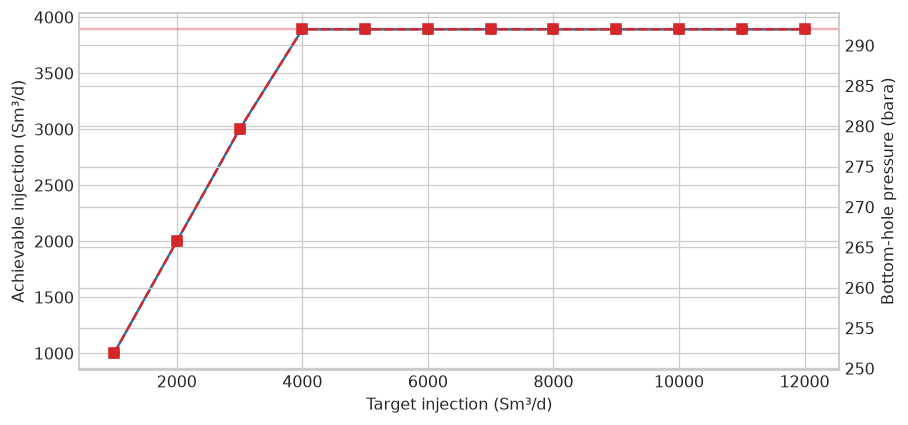

In [7]:
InjectionWellModel = JClass("neqsim.process.fielddevelopment.reservoir.InjectionWellModel")
InjectionType = JClass("neqsim.process.fielddevelopment.reservoir.InjectionWellModel$InjectionType")
injector = InjectionWellModel(InjectionType.WATER_INJECTOR)
injector.setReservoirPressure(238.0, "bara").setReservoirTemperature(82.0, "C")
injector.setFormationPermeability(180.0, "mD").setFormationThickness(42.0, "m").setSkinFactor(2.5)
injector.setWellDepth(3050.0, "m").setTubingID(0.127, "m")
injector.setMaxBHP(292.0, "bara").setFracturePressure(305.0, "bara").setSurfaceInjectionPressure(155.0, "bara")

injection_rows = []
for target in np.linspace(1000, 12000, 12):
    r = injector.calculate(float(target))
    injection_rows.append({"target_Sm3d": target, "achievable_Sm3d": float(r.getAchievableRate()),
                           "BHP_bara": float(r.getBottomholePressure()), "WHP_bara": float(r.getWellheadPressure()),
                           "pump_kW": float(r.getPumpPower()), "pressure_limited": bool(r.limitedByPressure)})
injection = pd.DataFrame(injection_rows)
assert (injection.achievable_Sm3d <= injection.target_Sm3d + 1e-6).all()
display(injection.round(2))

fig, ax1 = plt.subplots(figsize=(8, 3.8)); ax2 = ax1.twinx()
ax1.plot(injection.target_Sm3d, injection.achievable_Sm3d, "o-", label="Achievable rate")
ax2.plot(injection.target_Sm3d, injection.BHP_bara, "s--", color="#d62728", label="BHP")
ax2.axhline(292, color="#d62728", alpha=.35, label="Max BHP")
ax1.set(xlabel="Target injection (Sm³/d)", ylabel="Achievable injection (Sm³/d)")
ax2.set_ylabel("Bottom-hole pressure (bara)"); fig.tight_layout(); plt.show()


## 5. Intervention: evidence before action

Annulus pressure and bleed/rebuild behavior are screened against MAASP and well-integrity rules. If an intervention is justified and carbonate scale is suspected, NeqSim estimates acid capacity, scale dissolved, CO₂ generated, spent-acid condition, and warnings. The output supports—but never replaces—barrier verification, program review, chemistry tests, and authorization.


In [8]:
Integrity = JClass("neqsim.process.mechanicaldesign.subsea.WellIntegrityScreening")
Reading = JClass("neqsim.process.mechanicaldesign.subsea.WellIntegrityScreening$AnnulusReading")
integrity = Integrity("A-12")
integrity.setWellType("OIL_PRODUCER")
integrity.addAnnulus(Reading("A", 34.0, 80.0).setBleedsToZero(False).setRebuildsAfterBleed(True).setThermalEffectsExcluded(True))
integrity.addAnnulus(Reading("B", 4.0, 60.0).setBleedsToZero(True).setRebuildsAfterBleed(False).setThermalEffectsExcluded(True))
disposition = integrity.screen()
annulus_table = pd.DataFrame([{"annulus": str(k), "classification": str(v)}
                              for k, v in integrity.getAnnulusResults().entrySet()])
display(annulus_table)

Acid = JClass("neqsim.process.chemistry.acid.AcidTreatmentSimulator")
AcidType = JClass("neqsim.process.chemistry.acid.AcidTreatmentSimulator$AcidType")
acid = Acid(); acid.setAcidType(AcidType.HCL); acid.setAcidStrengthWtPct(15.0); acid.setAcidVolumeM3(12.0)
acid.setScaleCaCO3Kg(1450.0); acid.setScaleMgCO3Kg(120.0); acid.setTemperatureCelsius(68.0)
acid.setTubularMaterial("13Cr"); acid.setInhibitorPresent(True); acid.evaluate()
intervention = pd.DataFrame({"metric": ["Integrity disposition", "Dissolvable scale", "Scale dissolved",
                                         "Dissolution", "CO2 generated", "Spent-acid pH"],
                             "value": [str(disposition), acid.getDissolvableScaleKg(), acid.getScaleDissolvedKg(),
                                       acid.getDissolutionFractionPct(), acid.getCO2GeneratedKg(), acid.getSpentAcidPH()],
                             "unit": ["screen", "kg", "kg", "%", "kg", "-"]})
assert acid.isEvaluated() and 0 <= acid.getDissolutionFractionPct() <= 100
display(intervention)
display(pd.DataFrame({"screening finding": list(dict.fromkeys(map(str, integrity.getFindings()))) }))


,annulus,classification
0,A,SUSTAINED_CASING_PRESSURE
1,B,NORMAL


,metric,value,unit
0,Integrity disposition,INTERVENTION_REQUIRED,screen
1,Dissolvable scale,"1,570",kg
2,Scale dissolved,"1,570",kg
3,Dissolution,100,%
4,CO2 generated,700.2,kg
5,Spent-acid pH,-0.2293,-


,screening finding
0,FAIL: Annulus A rebuilds after bleed-down - su...
1,SCREEN: Severe indicator(s) present - interven...


## 6. Put the lifecycle together

The output of one discipline is an input or constraint for the next. A trajectory and completion are not isolated designs: they determine deliverability, lift/injection options, surveillance signatures, and intervention access. The facility and asset-management notebooks consume the potential rates, utility loads, reliability consequences, water/sand loads, and chemical needs produced here.


In [9]:
handoffs = pd.DataFrame([
    ["Drilling", "MD/TVD/DLS and casing basis", "Completion accessibility and cost"],
    ["Completion", "PI, skin, barrier architecture", "Natural-flow and artificial-lift envelope"],
    ["Production", "rate, pressure, water cut, GOR, power", "Facility capacity and production potential"],
    ["Injection", "rate/BHP/power and water-quality need", "Pressure support and flow assurance"],
    ["Intervention", "integrity disposition and treatment returns", "Downtime, restored PI, waste/emissions"],
])
handoffs.columns = ["stage", "governed output", "downstream consumer"]
display(handoffs)
assert neqsim_commit and len(neqsim_jar_sha256) == 64 and lift_table.engineering_valid.any()
print("Engineering checks passed: trajectory, cost, lift, injection, and intervention screens are finite and linked.")


Engineering checks passed: trajectory, cost, lift, injection, and intervention screens are finite and linked.


,stage,governed output,downstream consumer
0,Drilling,MD/TVD/DLS and casing basis,Completion accessibility and cost
1,Completion,"PI, skin, barrier architecture",Natural-flow and artificial-lift envelope
2,Production,"rate, pressure, water cut, GOR, power",Facility capacity and production potential
3,Injection,rate/BHP/power and water-quality need,Pressure support and flow assurance
4,Intervention,integrity disposition and treatment returns,"Downtime, restored PI, waste/emissions"


## Further work and limits

- Replace the compact minimum-curvature implementation with the organization’s governed survey/well-planning package and uncertainty model.
- Couple detailed multiphase well hydraulics, transient restart, inflow history matching, lift vendor curves, and network constraints before sanction.
- Use field-calibrated injectivity, fracture, corrosion/scale, and barrier data; this notebook deliberately avoids claiming detailed design or regulatory approval.
- Continue with the operations/asset-management notebook for reliability and accounting, and the produced-water/sand/chemicals notebook for discharge and flow-assurance consequences.
- Execution findings are tracked in NeqSim issues [#2858](https://github.com/equinor/neqsim/issues/2858) (negative feasible lift result) and [#2860](https://github.com/equinor/neqsim/issues/2860) (duplicate annulus ingestion).
